<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/09.9_Text_Processing_and_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 9 - Pemrosesan Teks dan Klasifikasi Multikelas (Text Processing and Multiclass Classification)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 9 Text Processing and Multiclass Classification** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Muat perpustakaan
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import movie_reviews
import matplotlib.pyplot as plt

# Unduh data NLTK jika belum ada (khususnya korpus movie_reviews)
try:
    movie_reviews.sents()
except LookupError:
    nltk.download('movie_reviews')

# Muat kumpulan data dari korpus NLTK movie_reviews
documents = []
labels = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append(movie_reviews.raw(fileid))
        labels.append(category)

# Ubah label menjadi numerik (0 untuk 'neg', 1 untuk 'pos')
label_map = {label: i for i, label in enumerate(sorted(list(set(labels))))}
numerical_labels = [label_map[label] for label in labels]


# Pisahkan datanya
# Menggunakan subset yang lebih kecil untuk tujuan demonstrasi guna mempercepat pemrosesan
# dan mengurangi penggunaan memori, karena korpus movie_reviews lengkap cukup besar.
# Anda dapat menyesuaikan subset_size atau menghapus pengambilan sampel ini untuk penggunaan set data secara penuh.
subset_size = 500 # Using 500 samples for quicker demonstration
if len(documents) > subset_size:
    # Pengambilan sampel bertingkat untuk mempertahankan proporsi kelas
    texts_subset, _, labels_subset, _ = train_test_split(
        documents, numerical_labels, train_size=subset_size, stratify=numerical_labels, random_state=2024
    )
else:
    texts_subset = documents
    labels_subset = numerical_labels

X_train, X_test, y_train, y_test = train_test_split(texts_subset, labels_subset, test_size=0.3, random_state=2024, stratify=labels_subset)

### Bagaimana cara melakukannya...
Pertama, kita akan mengubah teks mentah menjadi representasi numerik menggunakan `CountVectorizer()` dari scikit-learn.

In [2]:
# Buat instance dan sesuaikan CountVectorizer() dengan penghapusan stopword
vectorizer = CountVectorizer(stop_words='english')
X_train_vect = vectorizer.fit_transform(X_train)

# Transformasikan data uji
X_test_vect = vectorizer.transform(X_test)

### Cara kerjanya...
`CountVectorizer()` mengonversi data teks menjadi matriks jumlah token yang jarang, dengan setiap baris mewakili dokumen, dan setiap kolom mewakili token unik. Dalam konteks pemrosesan teks, token dapat merujuk pada unit dasar teks – kata, kalimat, paragraf, atau bahkan satu huruf, semuanya dapat dianggap sebagai token, bergantung pada penerapannya. Representasi numerik ini cocok untuk melatih berbagai model pembelajaran mesin. Fungsi `CountVectorizer()` menghitung kemunculan semua kata (unit token default dalam kasus ini) dalam setiap dokumen

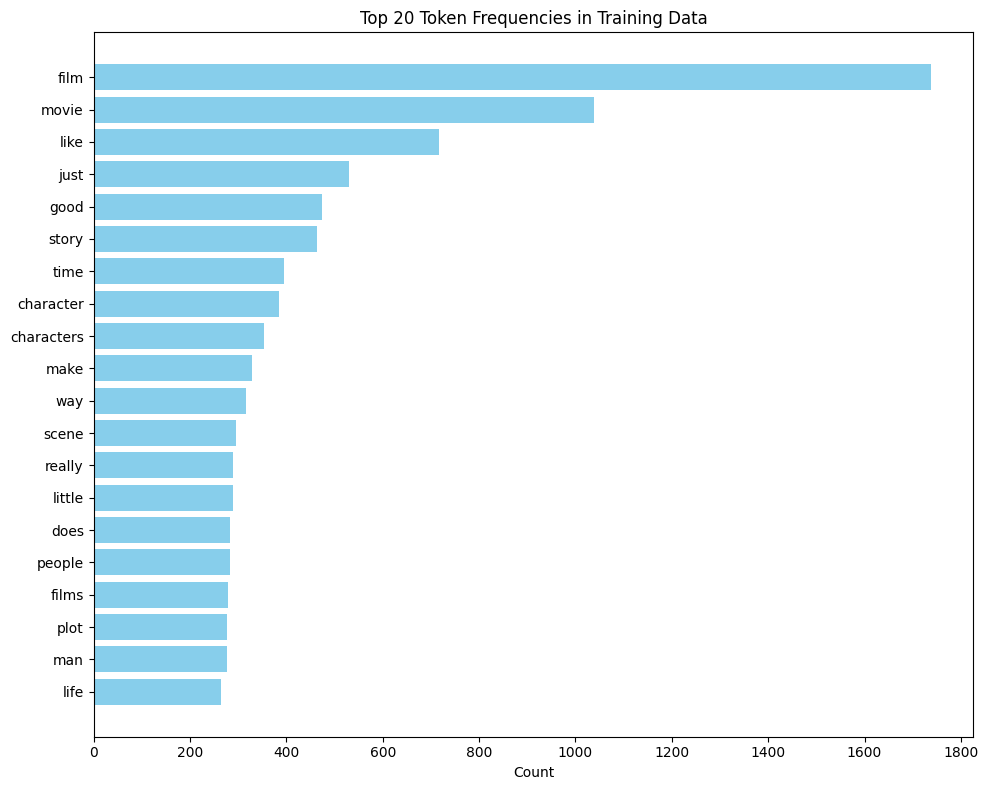

In [3]:
# Memvisualisasikan jumlah token
feature_names = vectorizer.get_feature_names_out()
counts = X_train_vect.toarray().sum(axis=0)

top_n = 20 # Display top N features
num_features = len(feature_names) # Should be equal to len(counts)

if num_features > 0:
    # Urutkan fitur berdasarkan hitungan
    # argsort mengurutkan dalam urutan menaik, [::-1] membalikkannya untuk menurun
    sorted_indices = np.argsort(counts)[::-1] 
    
    actual_top_n = min(top_n, num_features)

    # Pilih N fitur teratas dan jumlahnya
    top_feature_names = feature_names[sorted_indices][:actual_top_n]
    top_counts = counts[sorted_indices][:actual_top_n]

    plt.figure(figsize=(10, 8)) # Adjusted figsize for better readability of N items
    plt.barh(top_feature_names, top_counts, color='skyblue')
    plt.xlabel('Count')
    plt.title(f'Top {actual_top_n} Token Frequencies in Training Data')

    # Tetapkan tanda centang sumbu x secara dinamis menggunakan MaxNLocator untuk jumlah bilangan bulat
    from matplotlib.ticker import MaxNLocator
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(left=0) # Ensure x-axis starts at 0

    ax.invert_yaxis() # Display the highest count at the top
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else: # num_features == 0
    # Penggantian jika tidak ada fitur (misalnya, jika CountVectorizer tidak menemukan kata)
    plt.figure(figsize=(10,6)) # Use original figsize for this fallback
    plt.text(0.5, 0.5, 'No features to display.', ha='center', va='center')
    plt.title('Token Frequency in Training Data')
    plt.xticks([]) # No x-ticks
    plt.yticks([]) # No y-ticks
    plt.show()


## Teknik Vektorisasi Teks
Teknik vektorisasi teks mengubah teks mentah menjadi representasi numerik, memungkinkan algoritme ML menganalisis data tekstual secara efektif. Teknik seperti Bag of Words (BoW), TF-IDF, dan penyematan kata menawarkan pendekatan berbeda untuk menangkap fitur tekstual dan makna semantik. Namun, perlu diingat bahwa bahkan sebelum vektorisasi teks dimulai, komputer masih harus memiliki cara untuk merepresentasikan sebuah huruf. Hal ini biasanya dilakukan dengan menggunakan pengkodean ASCII atau Unicode sebagai cara awal untuk merepresentasikan dan menyimpan teks dalam memori komputer.

### Bersiap
Kami akan memuat perpustakaan yang diperlukan dan menyiapkan data tekstual untuk vektorisasi. Kali ini kita akan menggunakan korpus `reuters` dari NLTK. Ini berisi 10.788 dokumen berita dan sekitar 1,3 juta kata dengan lebih dari 90 kemungkinan kategori untuk klasifikasi. Kami hanya akan mengklasifikasikan berdasarkan kategori pertama untuk mempermudah.

In [4]:
# Muat perpustakaan
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import reuters
import matplotlib.pyplot as plt

# Unduh korpus Reuters jika belum diunduh
try:
    reuters.fileids()
except LookupError:
    nltk.download('reuters')

# Muat kumpulan data dari korpus NLTK Reuters
documents = reuters.fileids()
texts = [reuters.raw(doc_id) for doc_id in documents]

labels = [reuters.categories(doc_id)[0] for doc_id in documents] # Using the first category as the label for simplicity

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.5, random_state=2024)

### Bagaimana cara melakukannya...
Kami akan mendemonstrasikan vektorisasi teks menggunakan tiga teknik umum: BoW, TF-IDF, dan membahas secara singkat penyematan kata.

In [5]:
# Kantong Kata (BoW)
# Buat instance dan sesuaikan CountVectorizer()
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# Vektorisasi TF-IDF
# Buat instance dan sesuaikan TfidfVectorizer()
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

### Cara kerjanya...
- **Bag of Words (BoW)** mewakili teks sebagai jumlah frekuensi kata individual, dengan mengabaikan urutan kata dan tata bahasa.
- **TF-IDF** menyesuaikan frekuensi kata dengan mempertimbangkan kelangkaannya di seluruh dokumen, sehingga memberikan bobot yang lebih tinggi pada istilah yang berbeda. Teknik ini sedikit lebih rumit dibandingkan BoW dan memungkinkan klasifikasi dokumen berdasarkan kemunculan kata dengan lebih efisien.

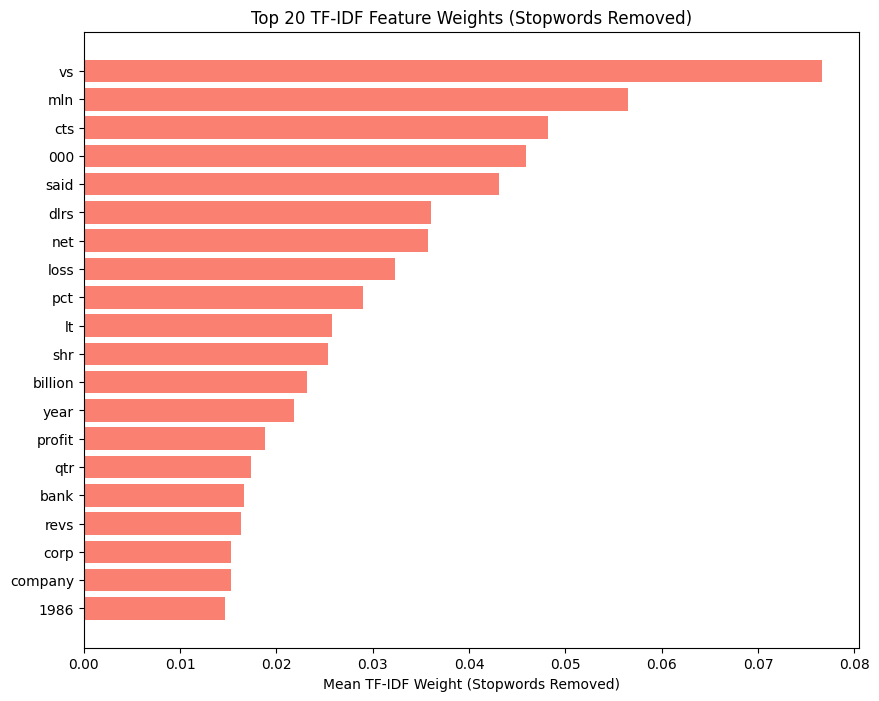

In [6]:
# Memvisualisasikan 20 bobot fitur TF-IDF teratas
# Buat instance TfidfVectorizer dengan kata-kata berhenti dalam bahasa Inggris dihapus
vis_tfidf_vectorizer = TfidfVectorizer(stop_words='english')
vis_X_train_tfidf = vis_tfidf_vectorizer.fit_transform(X_train)

# Dapatkan nama fitur dan rata-rata bobot TF-IDF dari vektorisasi baru ini
feature_names = vis_tfidf_vectorizer.get_feature_names_out()
tfidf_means = vis_X_train_tfidf.toarray().mean(axis=0)

# Jumlah istilah teratas untuk ditampilkan
N = 20

# Pastikan N tidak lebih besar dari jumlah fitur yang tersedia
if len(feature_names) < N:
    N = len(feature_names)

# Dapatkan indeks dari N sarana TF-IDF terbesar.
# np.argsort mengurutkan dalam urutan menaik, jadi kami mengambil N indeks terakhir.
# Indeks ini akan sesuai dengan N fitur dengan skor TF-IDF tertinggi,
# diurutkan dari tertinggi ke-N hingga tertinggi ke-1 (cocok untuk plt.barh untuk memplot tertinggi di atas).
if N > 0 : # Proceed only if there are features to plot
    sorted_indices_ascending = np.argsort(tfidf_means)
    top_n_plotting_indices = sorted_indices_ascending[-N:]

    # Pilih N nama fitur teratas dan cara TF-IDFnya menggunakan indeks ini
    plot_feature_names = feature_names[top_n_plotting_indices]
    plot_tfidf_means = tfidf_means[top_n_plotting_indices]

    # Buat plotnya
    plt.figure(figsize=(10, 8)) # Adjusted figsize for better readability with 20 items
    plt.barh(plot_feature_names, plot_tfidf_means, color='salmon')
    plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
    plt.title(f'Top {N} TF-IDF Feature Weights (Stopwords Removed)')
else: # Handle case with no features (e.g., if all features were stopwords or N=0)
    plt.figure(figsize=(10, 6)) # Original figsize for empty or minimal plot
    plt.barh([], []) # Plot empty data
    plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)')
    plt.title('TF-IDF Feature Weights (No non-stopword features to display)')

plt.show()

## Ekstraksi Fitur dari Teks
Ekstraksi fitur dari teks sangat penting untuk meningkatkan kinerja model klasifikasi teks dengan mengidentifikasi pola dan atribut yang bermakna dalam data tekstual. Teknik seperti n-gram, penandaan part-of-speech (POS), dan pengenalan entitas bernama (NER) memberikan wawasan terstruktur ke dalam konten tekstual, sehingga secara signifikan meningkatkan akurasi dan kemampuan interpretasi model.

### Bersiap
Kami akan memuat perpustakaan penting dan menyiapkan kumpulan data untuk ekstraksi fitur. Di sini kita akan menggunakan Brown Corpus yang juga ada di dalam perpustakaan NLTK. Ini berisi 500 kategori sumber berdasarkan genre.

In [7]:
# Muat perpustakaan
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import brown
from nltk.util import ngrams as nltk_ngrams
import matplotlib.pyplot as plt
from collections import Counter 
import nltk 
from nltk.corpus import stopwords 

# Unduh data NLTK yang diperlukan (jika belum ada)
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)

# Muat kumpulan data menggunakan korpus Brown
texts = []
labels = []

# Tentukan kategori yang akan digunakan dan jumlah kalimat per kategori
# Kita akan menggunakan dua kategori pertama dari korpus Brown untuk contoh ini
# dan ambil sejumlah kecil kalimat dari masing-masing kalimat.
# Ini akan membuat kumpulan data kecil yang cocok untuk demonstrasi.
categories_to_use = brown.categories()[:2]  # Example: ['adventure', 'belles_lettres']
num_sents_per_category = 2  # Number of sentences to extract from each category

for i, category in enumerate(categories_to_use):
    # Dapatkan kalimat untuk kategori saat ini
    # brown.sents() mengembalikan daftar kalimat, di mana setiap kalimat adalah daftar token.
    category_sents = brown.sents(categories=category)
    
    # Ambil jumlah kalimat yang ditentukan dari awal daftar
    for sent_tokens in category_sents[:num_sents_per_category]:
        texts.append(" ".join(sent_tokens))  # Join tokens to form a single string sentence
        labels.append(i)  # Assign a numerical label based on the category index

# Pada titik ini, 'teks' akan berisi 2*num_sents_per_category kalimat,
# dan 'label' akan berisi label bilangan bulat yang sesuai (misalnya, [0, 0, 1, 1] jika num_sents_per_category=2)

# Pisahkan datanya
# Kumpulan data akan memiliki 4 sampel jika num_sents_per_category=2.
# test_size=0.5 akan menghasilkan 2 sampel pelatihan dan 2 sampel pengujian.
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.5, random_state=2024)


### Bagaimana cara melakukannya...
Kami akan mendemonstrasikan ekstraksi fitur teks yang bermakna menggunakan n-gram, penandaan POS, dan NER.

In [8]:
# Ekstraksi N-gram
# Buat instance dan sesuaikan CountVectorizer() dengan n-gram
ngram_vectorizer = CountVectorizer(ngram_range=(1,2))
X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

# Penandaan Part-of-Speech (POS) menggunakan NLTK
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Contoh penandaan POS
print("--- POS Tagging of Tokens and N-grams in Training Sentences ---")
for i, text in enumerate(X_train):
    print(f"\nOriginal Sentence {i+1}: \"{text}\"")
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens) # This returns a list of (token, TAG) tuples

    # Menampilkan unigram yang diberi tag (token individual dengan tagnya)
    print("  Tagged Tokens (Unigrams):")
    if pos_tags: # Check if list is not empty
        # Formatnya sebagai: token1/TAG1 token2/TAG2 ...
        unigram_str = " ".join([f"{token}/{tag}" for token, tag in pos_tags])
        print(f"    {unigram_str}")
    else:
        print("    (No tokens to tag)")

    # Tampilkan bigram yang diberi tag
    # Bigram di sini berarti dua pasang (token, TAG) yang berurutan
    if len(pos_tags) >= 2:
        print("  Tagged Bigrams:")
        # nltk_ngrams pada pos_tags akan menghasilkan tupel seperti ( (token1, TAG1), (token2, TAG2) )
        tagged_bigrams = list(nltk_ngrams(pos_tags, 2))
        for bigram_tuple in tagged_bigrams:
            # bigram_tuple adalah, misalnya, (('The', 'DT'), ('quick', 'JJ'))
            # item1 adalah ('The', 'DT'), item2 adalah ('cepat', 'JJ')
            item1, item2 = bigram_tuple 
            # Formatnya sebagai: token1/TAG1 token2/TAG2
            bigram_display_str = f"{item1[0]}/{item1[1]} {item2[0]}/{item2[1]}"
            print(f"    {bigram_display_str}")
    else:
        print("  (Not enough tagged tokens for bigrams)")
        
print("\n--- End of POS Tagging Display ---")

--- POS Tagging of Tokens and N-grams in Training Sentences ---

Original Sentence 1: "Northern liberals are the chief supporters of civil rights and of integration ."
  Tagged Tokens (Unigrams):
    Northern/NNP liberals/NNS are/VBP the/DT chief/JJ supporters/NNS of/IN civil/JJ rights/NNS and/CC of/IN integration/NN ./.
  Tagged Bigrams:
    Northern/NNP liberals/NNS
    liberals/NNS are/VBP
    are/VBP the/DT
    the/DT chief/JJ
    chief/JJ supporters/NNS
    supporters/NNS of/IN
    of/IN civil/JJ
    civil/JJ rights/NNS
    rights/NNS and/CC
    and/CC of/IN
    of/IN integration/NN
    integration/NN ./.

Original Sentence 2: "Dan Morgan told himself he would forget Ann Turner ."
  Tagged Tokens (Unigrams):
    Dan/NNP Morgan/NNP told/VBD himself/PRP he/PRP would/MD forget/VB Ann/NNP Turner/NNP ./.
  Tagged Bigrams:
    Dan/NNP Morgan/NNP
    Morgan/NNP told/VBD
    told/VBD himself/PRP
    himself/PRP he/PRP
    he/PRP would/MD
    would/MD forget/VB
    forget/VB Ann/NNP
    An

### Cara kerjanya...
- **N-gram** menangkap rangkaian kata, memberikan konteks yang mungkin terlewatkan oleh setiap kata. Huruf “N” dalam n-gram merujuk pada jumlah kata yang dipertimbangkan secara kolektif. Misalnya, dalam keluaran Kalimat Asli 1 dari keluaran Python, kita memiliki “bigram” (yaitu, 2 kata). N-gram juga dikumpulkan secara tumpang tindih satu sama lain, jadi di Kalimat Asli 2, bigramnya adalah “Dan Morgan”, “Morgan memberitahu”, dll.
- **Penandaan POS** mengategorikan kata ke dalam jenis tata bahasa, memungkinkan model memanfaatkan struktur sintaksis.
- **NER** mengidentifikasi dan mengklasifikasikan entitas bernama seperti orang, organisasi, dan lokasi, sehingga memperkaya analisis data tekstual.

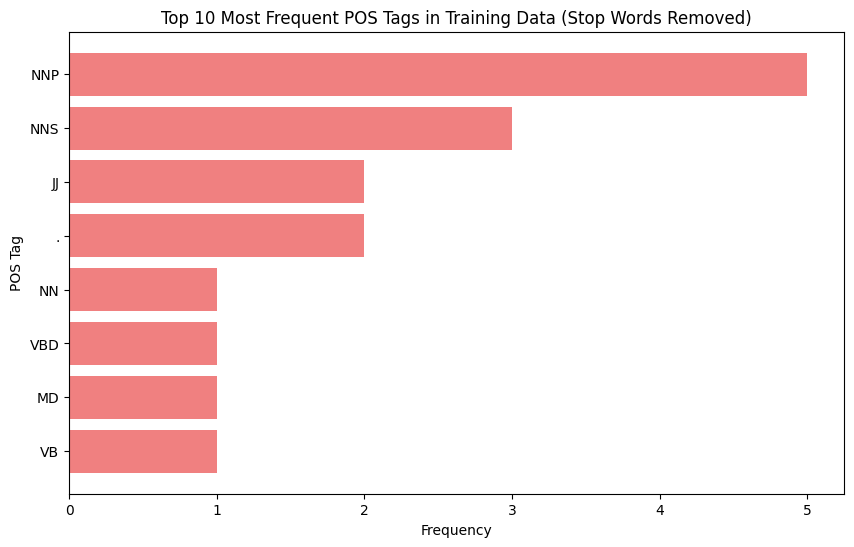

In [9]:
# Memvisualisasikan frekuensi tag POS
nltk.download('stopwords', quiet=True)

# Dapatkan kumpulan kata-kata berhenti bahasa Inggris untuk pencarian yang efisien
stop_words_set = set(stopwords.words('english'))

all_individual_pos_tags = []

# Ulangi setiap teks di X_train untuk mengekstrak tag POS
# X_train diasumsikan sebagai daftar string (kalimat) dari sel sebelumnya.
for text_content in X_train:
    tokens = nltk.word_tokenize(text_content) # Split text into words
    
    # Saring kata-kata berhenti. Perbandingan tidak membedakan huruf besar-kecil.
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words_set]

    # Jika kalimat menjadi kosong setelah penghapusan kata berhenti (misalnya, semua token adalah kata berhenti),
    # atau jika kalimat aslinya kosong, lompat ke kalimat berikutnya.
    if not filtered_tokens:
        continue
        
    # Lakukan penandaan Part-of-Speech pada token yang difilter.
    # Ini mengembalikan daftar tupel (token, TAG), misalnya, [('cat', 'NN'), ('sat', 'VBD')]
    pos_tagged_tokens = nltk.pos_tag(filtered_tokens) 

    # Ekstrak dan simpan hanya tag POS (bagian TAG)
    for _, tag in pos_tagged_tokens: # We only need the tag, not the token itself for this visualization
        all_individual_pos_tags.append(tag)

# Hitung frekuensi semua tag POS individual yang dikumpulkan
pos_tag_counter = Counter(all_individual_pos_tags)

# Dapatkan 10 tag POS paling umum dan jumlahnya (atau semuanya jika kurang dari 10)
top_10_pos_tags = pos_tag_counter.most_common(10)

# Periksa apakah ada tag POS yang ditemukan sebelum mencoba membuat plot
if top_10_pos_tags:
    # Buka zip daftar tupel (tag, hitung) menjadi dua daftar terpisah
    tags, counts = zip(*top_10_pos_tags)

    plt.figure(figsize=(10,6)) # plt is assumed to be imported as matplotlib.pyplot
    # Buat diagram batang horizontal; mengonversi tupel dari zip ke daftar untuk diplot
    plt.barh(list(tags), list(counts), color='lightcoral')
    plt.xlabel('Frequency')
    plt.ylabel('POS Tag')
    plt.title('Top 10 Most Frequent POS Tags in Training Data (Stop Words Removed)')
    plt.gca().invert_yaxis() # Invert y-axis to show the most frequent item at the top
    plt.show()
else:
    # Pesan ini ditampilkan jika X_train kosong, semua token adalah kata-kata berhenti,
    # atau tidak ada token yang tersisa setelah difilter untuk diberi tag.
    print("No POS tags found to display. Check X_train data and stop word filtering process.")

## Menerapkan Model Klasifikasi Teks
Menerapkan model klasifikasi teks memungkinkan kita mengkategorikan data tekstual secara efektif, seperti analisis sentimen atau klasifikasi topik. Dengan menggunakan scikit-learn, kita dapat menggunakan algoritme populer termasuk Naive Bayes, Support Vector Machines (SVM), dan Logistic Regression untuk memprediksi kategori secara akurat berdasarkan masukan tekstual.

### Bersiap
Kita akan mulai dengan mempersiapkan lingkungan dan data untuk pemodelan klasifikasi.

In [10]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import brown
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report 

# Unduh sumber daya NLTK (jika belum diunduh)
# Merupakan praktik yang baik untuk memasukkan ini, meskipun dalam buku catatan sungguhan,
# itu mungkin dijalankan sekali dalam sel terpisah.
try:
    nltk.data.find('corpora/brown.zip')
except nltk.downloader.DownloadError:
    nltk.download('brown', quiet=True)
try:
    # Punkt adalah ketergantungan tokenizer untuk beberapa operasi korpus NLTK.
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt', quiet=True)

# Muat kumpulan data dari korpus NLTK Brown
document_ids = brown.fileids()
texts = [' '.join(brown.words(file_id)) for file_id in document_ids]
# Setiap dokumen dalam korpus Brown ditetapkan ke dalam kategori (genre).
# Kami menggunakan kategori pertama sebagai label.
raw_labels = [brown.categories(file_id)[0] for file_id in document_ids]

# Ubah label string (kategori) menjadi label numerik untuk scikit-learn
unique_raw_labels = sorted(list(set(raw_labels)))
label_to_int_mapping = {label: i for i, label in enumerate(unique_raw_labels)}
labels = [label_to_int_mapping[label] for label in raw_labels]

# Pisahkan datanya
# Korpus Brown memiliki 500 dokumen dan 15 kategori.
# Jumlah minimum sampel per kategori adalah >20, jadi stratifikasi akan berfungsi dengan baik.
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.5, stratify=labels, random_state=2024)


### Bagaimana cara melakukannya...
Kami akan mengubah data tekstual dan melatih tiga model klasifikasi berbeda.

In [11]:
# Vektorisasi teks menggunakan TF-IDF
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Latih model Naive Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train_vect, y_train)

# Latih model SVM
svm_clf = SVC(random_state=2024)
svm_clf.fit(X_train_vect, y_train)

# Melatih model Logistic Regression
lr_clf = LogisticRegression(random_state=2024, max_iter=1000)
lr_clf.fit(X_train_vect, y_train)

# Evaluasi modelnya
models = {'Naive Bayes': nb_clf, 'SVM': svm_clf, 'Logistic Regression': lr_clf}
for name, model in models.items():
    y_pred = model.predict(X_test_vect)
    print(f'{name} Classification Report:')
    # Hasilkan laporan klasifikasi sebagai kamus
    # Gunakan label_raw_unik untuk nama_target untuk menampilkan nama kelas sebenarnya
    report_dict = classification_report(y_test, y_pred, target_names=unique_raw_labels, output_dict=True, zero_division=0)
    # Konversikan ke DataFrame
    report_df = pd.DataFrame(report_dict).transpose()
    
    # Sesuaikan gaya DataFrame
    styled_df = (report_df
        .style
        .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
        .format({
            'precision': '{:.3f}',
            'recall': '{:.3f}', 
            'f1-score': '{:.3f}',
            'support': '{:.0f}'
        })
    )
    display(styled_df)
    print("\n")

Naive Bayes Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,15
belles_lettres,0.173,1.000,0.295,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.556,0.500,0.526,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12


SVM Classification Report:


,precision,recall,f1-score,support
adventure,0.400,0.133,0.200,15
belles_lettres,0.236,0.946,0.378,37
editorial,0.000,0.000,0.000,14
fiction,0.312,0.357,0.333,14
government,0.000,0.000,0.000,15
hobbies,0.000,0.000,0.000,18
humor,0.000,0.000,0.000,4
learned,0.424,0.700,0.528,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12




Logistic Regression Classification Report:


,precision,recall,f1-score,support
adventure,1.000,0.067,0.125,15
belles_lettres,0.231,0.919,0.370,37
editorial,0.000,0.000,0.000,14
fiction,0.000,0.000,0.000,14
government,0.000,0.000,0.000,15
hobbies,1.000,0.056,0.105,18
humor,0.000,0.000,0.000,4
learned,0.377,0.725,0.496,40
lore,0.000,0.000,0.000,24
mystery,0.000,0.000,0.000,12


### Cara kerjanya...
Kami telah menjelajahi beberapa model ini sebelumnya dan seperti yang Anda lihat, setelah teks kami diproses sebelumnya, model tersebut juga berfungsi dengan baik dalam konteks ini.
- **Naive Bayes** berkinerja baik pada data teks karena sifat probabilistiknya dan efisiensi dalam menangani ruang fitur yang besar.
- **SVM** unggul dalam menangkap hubungan kompleks dengan menemukan hyperplane optimal untuk memisahkan kelas.
- **Logistic Regression** memberikan prediksi yang kuat dan probabilitas yang dapat ditafsirkan, sehingga berguna untuk tugas klasifikasi biner.

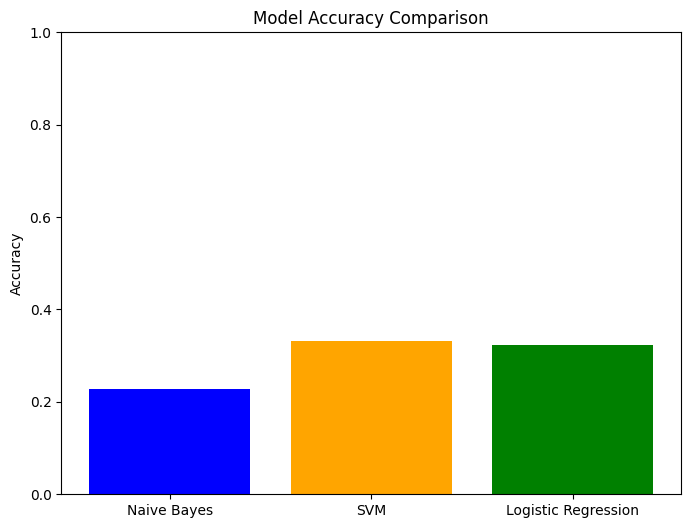

In [12]:
# Memvisualisasikan akurasi klasifikasi
model_accuracies = {}
for model_name, model_instance in models.items():
    y_pred = model_instance.predict(X_test_vect)
    # Menggunakan parameter yang konsisten dengan pembuatan laporan di sel sebelumnya.
    # Asumsikan label_mentah_unik ditentukan dan tersedia dari sel sebelumnya,
    # seperti yang digunakan di file_context_0 untuk menghasilkan laporan klasifikasi.
    # Parameter target_names tidak mempengaruhi nilai 'akurasi' keseluruhan tetapi disertakan untuk konsistensi.
    report_dict = classification_report(y_test, y_pred, target_names=unique_raw_labels, output_dict=True, zero_division=0)
    model_accuracies[model_name] = report_dict['accuracy']

plt.figure(figsize=(8,6))

# Merencanakan menggunakan akurasi yang dihitung
# .keys() dan .values() dari kamus yang sama akan berada dalam urutan yang sesuai.
plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()


## Strategi Klasifikasi Multikelas
Klasifikasi multikelas, seperti yang kita lihat sebelumnya di Bab 6, melibatkan prediksi kategori ketika terdapat lebih dari dua kelas. Berbagai strategi seperti klasifikasi satu lawan satu, satu lawan satu, dan klasifikasi hierarki membantu mengatasi masalah ini secara efektif. Dengan menggunakan scikit-learn, kita dapat menerapkan dan mengeksplorasi pendekatan ini untuk tugas klasifikasi teks.

### Bersiap
Kami akan menyiapkan lingkungan dan kumpulan data kami untuk menerapkan strategi klasifikasi multikelas.

In [13]:
# Muat perpustakaan
import nltk
from nltk.corpus import brown # Changed from webtext to brown
from sklearn.model_selection import train_test_split # Ensure this is available

# Unduh korpus coklat NLTK jika belum ada
# Menggunakan Quiet=True untuk menyembunyikan keluaran unduhan verbose di buku catatan
try:
    _ = brown.fileids() # Check if already downloaded and accessible
except LookupError:
    nltk.download('brown', quiet=True)
except Exception: # Catch other potential NLTK setup issues
    nltk.download('brown', quiet=True)

# Muat kumpulan data dari korpus coklat NLTK
file_ids = brown.fileids()
texts = [brown.raw(file_id) for file_id in file_ids]
# Gunakan genre file sebagai labelnya. Setiap file di Brown termasuk dalam satu genre.
labels = [brown.categories(file_id)[0] for file_id in file_ids]

# Pisahkan datanya
# Korpus Brown memiliki 500 dokumen.
# Test_size 0,3 akan menghasilkan 350 latih dan 150 sampel uji.
# Ini memberikan lebih banyak sampel secara signifikan dibandingkan pengujian 3 train/3 sebelumnya.
# Menambahkan stratify=labels untuk distribusi kelas yang lebih baik secara terpisah.
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.3, random_state=2024, stratify=labels)


### Bagaimana cara melakukannya...
Kami akan mendemonstrasikan dua strategi utama: klasifikasi satu lawan satu dan klasifikasi satu lawan satu.

In [14]:
# Vektorisasi teks menggunakan TF-IDF
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Menerapkan klasifikasi Satu-vs-Istirahat
ovr_clf = OneVsRestClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovr_clf.fit(X_train_vect, y_train)
y_pred_ovr = ovr_clf.predict(X_test_vect)

# Menerapkan klasifikasi Satu-vs-Satu
ovo_clf = OneVsOneClassifier(LogisticRegression(random_state=2024, solver='liblinear'))
ovo_clf.fit(X_train_vect, y_train)
y_pred_ovo = ovo_clf.predict(X_test_vect)

# Evaluasi Classifier
# Menambahkan zero_division=0 untuk menangani kasus di mana presisi/penarikan kembali mungkin tidak jelas
# karena tidak ada sampel yang diprediksi atau tidak ada sampel yang sebenarnya untuk suatu kelas.

print('One-vs-Rest Classification Report:')
report_ovr_dict = classification_report(y_test, y_pred_ovr, zero_division=0, output_dict=True)
report_ovr_df = pd.DataFrame(report_ovr_dict).transpose()
styled_ovr_df = (report_ovr_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovr_df)
print("\n")

print('One-vs-One Classification Report:')
report_ovo_dict = classification_report(y_test, y_pred_ovo, zero_division=0, output_dict=True)
report_ovo_df = pd.DataFrame(report_ovo_dict).transpose()
styled_ovo_df = (report_ovo_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovo_df)
print("\n")


One-vs-Rest Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,9
belles_lettres,0.224,0.773,0.347,22
editorial,0.000,0.000,0.000,8
fiction,0.000,0.000,0.000,9
government,0.000,0.000,0.000,9
hobbies,0.000,0.000,0.000,11
humor,0.000,0.000,0.000,3
learned,0.345,0.792,0.481,24
lore,0.000,0.000,0.000,14
mystery,0.000,0.000,0.000,7




One-vs-One Classification Report:


,precision,recall,f1-score,support
adventure,0.000,0.000,0.000,9
belles_lettres,0.185,0.773,0.298,22
editorial,0.000,0.000,0.000,8
fiction,0.000,0.000,0.000,9
government,0.000,0.000,0.000,9
hobbies,0.000,0.000,0.000,11
humor,0.000,0.000,0.000,3
learned,0.373,0.792,0.507,24
lore,0.000,0.000,0.000,14
mystery,0.000,0.000,0.000,7


### Cara kerjanya...
Sebagai penyegaran dari Bab 6, berikut adalah dua teknik yang kami gunakan untuk masalah klasifikasi yang menampilkan lebih dari satu kelas.
- **One-vs-Rest (OvR)**: Membangun satu Classifier per kelas, membedakan satu kelas dari semua kelas lainnya. Strategi ini efisien secara komputasi dan mudah.
- **Satu-vs-Satu (OvO)**: Membuat Classifier untuk setiap pasangan kelas, sehingga menghasilkan jumlah model yang lebih banyak, namun sering kali memberikan performa yang lebih baik pada kumpulan data yang seimbang.

## Mengevaluasi Model Teks
Mengevaluasi model teks melibatkan penggunaan metrik yang dirancang khusus untuk menilai kinerja tugas klasifikasi teks. Metrik seperti matriks presisi, perolehan, skor F1, dan Confusion Matrix memberikan wawasan mendetail tentang seberapa akurat dan efektif model kami mengklasifikasikan data tekstual, sehingga memungkinkan kami menafsirkan dan meningkatkan hasil model. Namun, meskipun berada di luar cakupan buku ini, LLM memerlukan teknik yang jauh lebih kompleks untuk mengevaluasi kinerjanya, terutama saat membuat teks dibandingkan menggunakannya dalam masalah ML yang lebih sederhana seperti klasifikasi. 

### Bersiap
Mari siapkan perpustakaan dan kumpulan data yang diperlukan untuk mengevaluasi model klasifikasi teks.

In [15]:
# Muat perpustakaan
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import movie_reviews
import random

# Unduh data NLTK (movie_reviews corpus) jika belum diunduh
try:
    # Periksa apakah korpus dapat diakses
    movie_reviews.categories()
except LookupError:
    nltk.download('movie_reviews')

# Muat kumpulan data dari korpus NLTK movie_reviews
documents = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append((list(movie_reviews.words(fileid)), category))

# Kocok dokumen untuk pemisahan yang lebih baik.
# Menggunakan benih tetap untuk reproduktifitas, konsisten dengan random_state di train_test_split.
random.seed(2024)
random.shuffle(documents)

# Siapkan teks (menggabungkan kata menjadi string) dan label
texts = [" ".join(words) for words, category in documents]
labels = [category for words, category in documents]

# Pisahkan datanya
# Pertahankan test_size dan random_state seperti pada pilihan awal
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.5, random_state=2024)


### Bagaimana cara melakukannya...
Kami akan menggunakan Logistic Regression sebagai contoh untuk mendemonstrasikan evaluasi model teks.

Precision: 0.8034174884733607
Recall: 0.803
F1 Score: 0.8029765558512367

Classification Report:


,precision,recall,f1-score,support
neg,0.791016,0.818182,0.804369,495.000000
pos,0.815574,0.788119,0.801611,505.000000
accuracy,0.803000,0.803000,0.803000,0.803000
macro avg,0.803295,0.803150,0.802990,1000.000000
weighted avg,0.803417,0.803000,0.802977,1000.000000


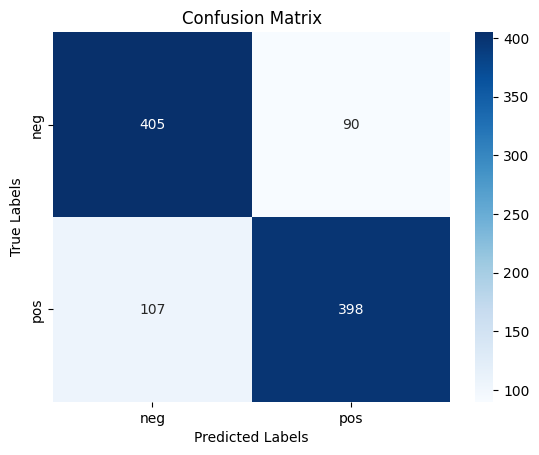

In [16]:
# Vektorisasi teks menggunakan TF-IDF
vectorizer = TfidfVectorizer()
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Latih Classifier Logistic Regression
clf = LogisticRegression(random_state=2024)
clf.fit(X_train_vect, y_train)

# Buatlah prediksi
y_pred = clf.predict(X_test_vect)

# Evaluasi modelnya
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

# Hasilkan laporan klasifikasi sebagai DataFrame bergaya
report_dict = classification_report(y_test, y_pred, labels=clf.classes_, target_names=clf.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("\nClassification Report:")
display(report_df.style.set_caption("Classification Report"))

# Hasilkan dan visualisasikan Confusion Matrix
# Fungsi confusion_matrix menghitung akurasi berdasarkan kelas.
# labels=clf.classes_ memastikan baris/kolom matriks mengikuti urutan yang konsisten.
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


### Cara kerjanya...
- **Presisi** mengukur keakuratan prediksi positif.
- **Recall (sensitivitas)** menilai kemampuan untuk mengidentifikasi kejadian positif.
- **Skor F1** memberikan ukuran yang seimbang dengan menggabungkan presisi dan perolehan.
- **Confusion Matrix** secara visual mewakili keakuratan prediksi untuk setiap kelas, membantu kami mengidentifikasi kesalahan klasifikasi dengan mudah.

## Latihan Praktis dengan Pengolahan Teks
Di bagian akhir ini, kita akan terlibat dalam latihan praktis yang melibatkan pra-pemrosesan data teks, melakukan vektorisasi, mengekstraksi fitur-fitur yang bermakna, dan membuat model klasifikasi multikelas. Latihan-latihan ini dirancang untuk memperkuat konsep-konsep yang dipelajari sepanjang bab ini dan menunjukkan bagaimana menerapkan teknik pemrosesan dan klasifikasi teks secara efektif dalam berbagai skenario. Di akhir bagian ini, kita akan memiliki pengalaman langsung untuk diterapkan dalam proyek pembelajaran mesin kita sendiri.

### Latihan 1: Memproses Awal dan Membuat Vektorisasi Teks
Dalam latihan ini, kita akan memproses data teks mentah terlebih dahulu dan mengubahnya menjadi fitur numerik menggunakan teknik vektorisasi.

In [17]:
# Memuat perpustakaan
from sklearn.feature_extraction.text import TfidfVectorizer

# Muat Set Data
texts = [
    "Data preprocessing is essential.",
    "Vectorization transforms text.",
    "Clean data improves model performance.",
    "Machine learning algorithms use numerical data."
]

# Praproses Data (pembersihan dasar)
texts_cleaned = [text.lower() for text in texts]

# Vektorisasikan Teks
vectorizer = TfidfVectorizer()
vectorizer.fit_transform(texts_cleaned)

# Cetak fitur yang divektorkan
vectorizer.get_feature_names_out()


array(['algorithms', 'clean', 'data', 'essential', 'improves', 'is',
       'learning', 'machine', 'model', 'numerical', 'performance',
       'preprocessing', 'text', 'transforms', 'use', 'vectorization'],
      dtype=object)

### Latihan 2: Ekstraksi Fitur dengan N-gram
Dalam latihan ini, kita akan mengekstrak fitur n-gram dari teks untuk menangkap konteks dengan lebih baik untuk tugas klasifikasi.

In [18]:
# Memuat perpustakaan
from sklearn.feature_extraction.text import CountVectorizer

# Muat Set Data
texts = [
    "Feature extraction is crucial.",
    "N-grams capture context.",
    "Models benefit from good features.",
    "Contextual information enhances classification."
]

# Ekstrak Fitur N-gram
ngram_vectorizer = CountVectorizer(ngram_range=(1,2))
ngram_vectorizer.fit_transform(texts)

# Cetak fitur n-gram yang diekstrak
ngram_vectorizer.get_feature_names_out()


array(['benefit', 'benefit from', 'capture', 'capture context',
       'classification', 'context', 'contextual',
       'contextual information', 'crucial', 'enhances',
       'enhances classification', 'extraction', 'extraction is',
       'feature', 'feature extraction', 'features', 'from', 'from good',
       'good', 'good features', 'grams', 'grams capture', 'information',
       'information enhances', 'is', 'is crucial', 'models',
       'models benefit'], dtype=object)

### Latihan 3: Membangun dan Mengevaluasi Classifier Multikelas
Di sini, kita akan membangun, melatih, dan mengevaluasi Classifier multikelas menggunakan Logistic Regression.

In [19]:
# Memuat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Muat Set Data
texts = [
    "This is an economic news article.",
    "Sports events are exciting.",
    "Technology advances rapidly.",
    "Politics affect global relations."
]
labels = ["Economy", "Sports", "Technology", "Politics"]

# Vektorisasi Teks
vectorizer = TfidfVectorizer()
X_vect = vectorizer.fit_transform(texts)

# Pisahkan Data
X_train, X_test, y_train, y_test = train_test_split(X_vect, labels, test_size=0.5, random_state=2024)

# Latih Classifier
clf = LogisticRegression(random_state=2024)
clf.fit(X_train, y_train)

# Buat Prediksi dan Evaluasi
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Economy       0.00      0.00      0.00       0.0
    Politics       0.00      0.00      0.00       1.0
      Sports       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah mempelajari cara menangani data teks dan klasifikasinya:
* **Vectorization:** Menggunakan `CountVectorizer` untuk representasi frekuensi kata (*Bag-of-Words*) dan `TfidfVectorizer` untuk memberikan pembobotan kata berdasarkan kepentingannya secara keseluruhan (TF-IDF).
* **Pembersihan Teks:** Menghapus kata umum yang kurang informatif (*stop words*) dan mengatur n-grams untuk menangkap urutan kata (frasa).
* **Klasifikasi Teks:** Menerapkan model klasifikasi multikelas pada fitur teks ter-vektorisasi.

#### 2. Pandangan ke Depan
Pemrosesan teks merupakan landasan penting dalam bidang pemrosesan bahasa alami (NLP). Setelah menyelesaikan berbagai modul pemodelan prediktif terarah (*supervised*), di **Bab 10** kita akan masuk ke ranah pembelajaran tidak terarah (*unsupervised learning*) untuk mengelompokkan data yang tidak memiliki label target menggunakan teknik clustering.